In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Set Root Directory
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Deep Learning Pipeline using device: {device}")

Deep Learning Pipeline using device: cpu


In [8]:
class StockSequenceDataset(Dataset):
    def __init__(self, X, y, seq_length=20):
        self.seq_length = seq_length
        self.X_seq, self.y_seq = [], []
        
        for i in range(len(X) - seq_length):
            self.X_seq.append(X[i : i + seq_length])
            self.y_seq.append(y[i + seq_length])
            
        self.X_seq = torch.tensor(np.array(self.X_seq), dtype=torch.float32)
        self.y_seq = torch.tensor(np.array(self.y_seq), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.y_seq[idx]

# Load and clean feature matrix
csv_files = [f for f in os.listdir(PROCESSED_DIR) if f.endswith(".csv")] if os.path.exists(PROCESSED_DIR) else []
target_file = "processed_features.csv" if "processed_features.csv" in csv_files else (csv_files[0] if csv_files else None)

if target_file:
    df = pd.read_csv(os.path.join(PROCESSED_DIR, target_file))
    numeric_df = df.select_dtypes(include=[np.number]).dropna()
else:
    # Synthetic dataset generator fallback
    np.random.seed(42)
    numeric_df = pd.DataFrame(np.random.randn(500, 5), columns=["Close", "RSI", "MACD", "Vol", "Target_Return"])

if "Target_Return" not in numeric_df.columns:
    numeric_df["Target_Return"] = numeric_df.iloc[:, 0].pct_change().shift(-1)
    numeric_df = numeric_df.dropna()

X_raw = numeric_df.drop(columns=["Target_Return"]).values
y_raw = numeric_df["Target_Return"].values

# Train/Test Split (80/20 chronological split)
split = int(len(X_raw) * 0.8)
seq_len = 20

train_dataset = StockSequenceDataset(X_raw[:split], y_raw[:split], seq_length=seq_len)
test_dataset = StockSequenceDataset(X_raw[split:], y_raw[split:], seq_length=seq_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Sequence Batches Created | Train Batches: {len(train_loader)} | Test Batches: {len(test_loader)}")

Sequence Batches Created | Train Batches: 75 | Test Batches: 19


In [9]:
# 1. LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# 2. BiLSTM Model
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        out, _ = self.bilstm(x)
        return self.fc(out[:, -1, :])

# 3. GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

# 4. Transformer Encoder Model
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

print("Deep Learning Models Loaded successfully.")

Deep Learning Models Loaded successfully.


[LSTM] Final Training Loss: 0.000942
[BiLSTM] Final Training Loss: 0.000942
[GRU] Final Training Loss: 0.000939
[Transformer] Final Training Loss: 0.001203


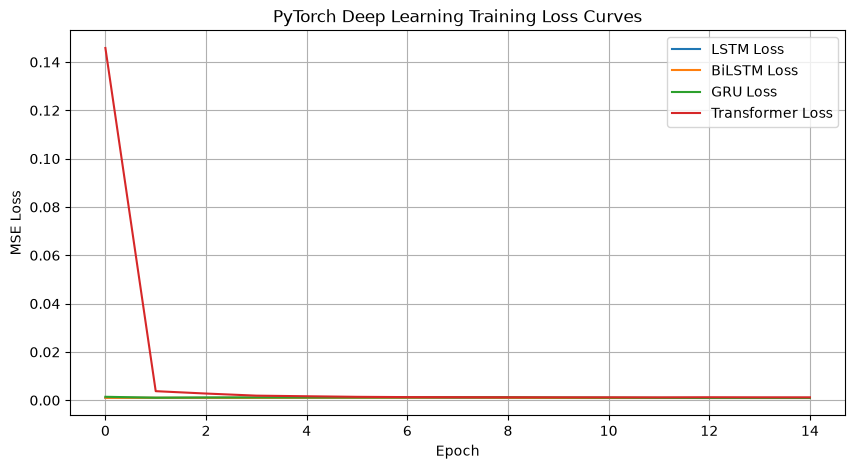

In [10]:
input_dim = X_raw.shape[1]
models = {
    "LSTM": LSTMModel(input_dim).to(device),
    "BiLSTM": BiLSTMModel(input_dim).to(device),
    "GRU": GRUModel(input_dim).to(device),
    "Transformer": TransformerModel(input_dim).to(device)
}

epochs = 15
history = {}

for name, model in models.items():
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_losses = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        train_losses.append(epoch_loss / len(train_loader))
        
    history[name] = train_losses
    print(f"[{name}] Final Training Loss: {train_losses[-1]:.6f}")

# Plot Loss Curves
plt.figure(figsize=(10, 5))
for name, losses in history.items():
    plt.plot(losses, label=f"{name} Loss")

plt.title("PyTorch Deep Learning Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()